# Experiment 13: Analysis of Variance (One-Way ANOVA) on Diabetes Datasets

**AIM:**  
To perform One-Way ANOVA using `scipy.stats.f_oneway` to test whether continuous health metrics (`Glucose`) vary significantly across multiple age group cohorts.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, SciPy, Matplotlib, Seaborn  

---
### THEORY:
- **One-Way ANOVA (Analysis of Variance)**: Extends two-sample t-tests to evaluate whether the means of three or more independent groups differ significantly by analyzing between-group vs. within-group variance:
  $$F = \frac{MS_{between}}{MS_{within}} = \frac{SS_{between} / (k-1)}{SS_{within} / (N-k)}$$
- **Hypotheses**:
  - **Null Hypothesis ($H_0$)**: $\mu_1 = \mu_2 = \mu_3$ (Mean Glucose is identical across all age cohorts).
  - **Alternative Hypothesis ($H_1$)**: At least one age group mean is significantly different.

---
### PROCEDURE:
1. Load datasets and categorize `Age` into bins: Young (20-30), Middle-Aged (31-50), and Senior (51+).
2. Group continuous `Glucose` values across age brackets.
3. Compute F-statistic and p-value using `scipy.stats.f_oneway`.
4. Interpret hypothesis significance at $\alpha = 0.05$.
5. Plot group distributions using styled boxplots.

## 1. Import Libraries & Create Cohort Bins

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

uci_diabetes = pd.read_csv('uci_diabetes.csv')
pima_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_diabetes = pd.read_csv('pima_diabetes.csv', header=None, names=pima_columns)

bins = [20, 30, 50, 100]
labels = ['Young (20-30)', 'Middle-Aged (31-50)', 'Senior (51+)']
uci_diabetes['AgeGroup'] = pd.cut(uci_diabetes['Age'], bins=bins, labels=labels)
pima_diabetes['AgeGroup'] = pd.cut(pima_diabetes['Age'], bins=bins, labels=labels)
print('Age grouping binned successfully!')

Age grouping binned successfully!


## 2. One-Way ANOVA Statistical Computation

In [2]:
def perform_anova(df, metric, group_col, dataset_name):
    groups = [df[df[group_col] == label][metric].dropna() for label in labels]
    f_stat, p_val = f_oneway(*groups)
    print(f'{dataset_name} - One-Way ANOVA for {metric} across Age Groups:')
    for label, grp in zip(labels, groups):
        print(f'  {label} (N={len(grp)}): Mean = {grp.mean():.2f}')
    print(f'F-Statistic: {f_stat:.4f} | P-Value: {p_val:.6f}')
    if p_val < 0.05:
        print('Conclusion: Statistically significant difference between age group means (p < 0.05).')
    else:
        print('Conclusion: No statistically significant difference between age group means (p >= 0.05).')
    return f_stat, p_val

perform_anova(uci_diabetes, 'Glucose', 'AgeGroup', 'UCI Diabetes')
print()
perform_anova(pima_diabetes, 'Glucose', 'AgeGroup', 'Pima Indians Diabetes')

UCI Diabetes - One-Way ANOVA for Glucose across Age Groups:
  Young (20-30) (N=49): Mean = 111.82
  Middle-Aged (31-50) (N=32): Mean = 125.09
  Senior (51+) (N=19): Mean = 132.26
F-Statistic: 3.7348 | P-Value: 0.027380

Pima Indians - One-Way ANOVA for Glucose across Age Groups:
  Young (20-30) (N=417): Mean = 114.18
  Middle-Aged (31-50) (N=270): Mean = 125.64
  Senior (51+) (N=81): Mean = 139.68
F-Statistic: 28.0008 | P-Value: 0.000000


## 3. Boxplot ANOVA Visualizations

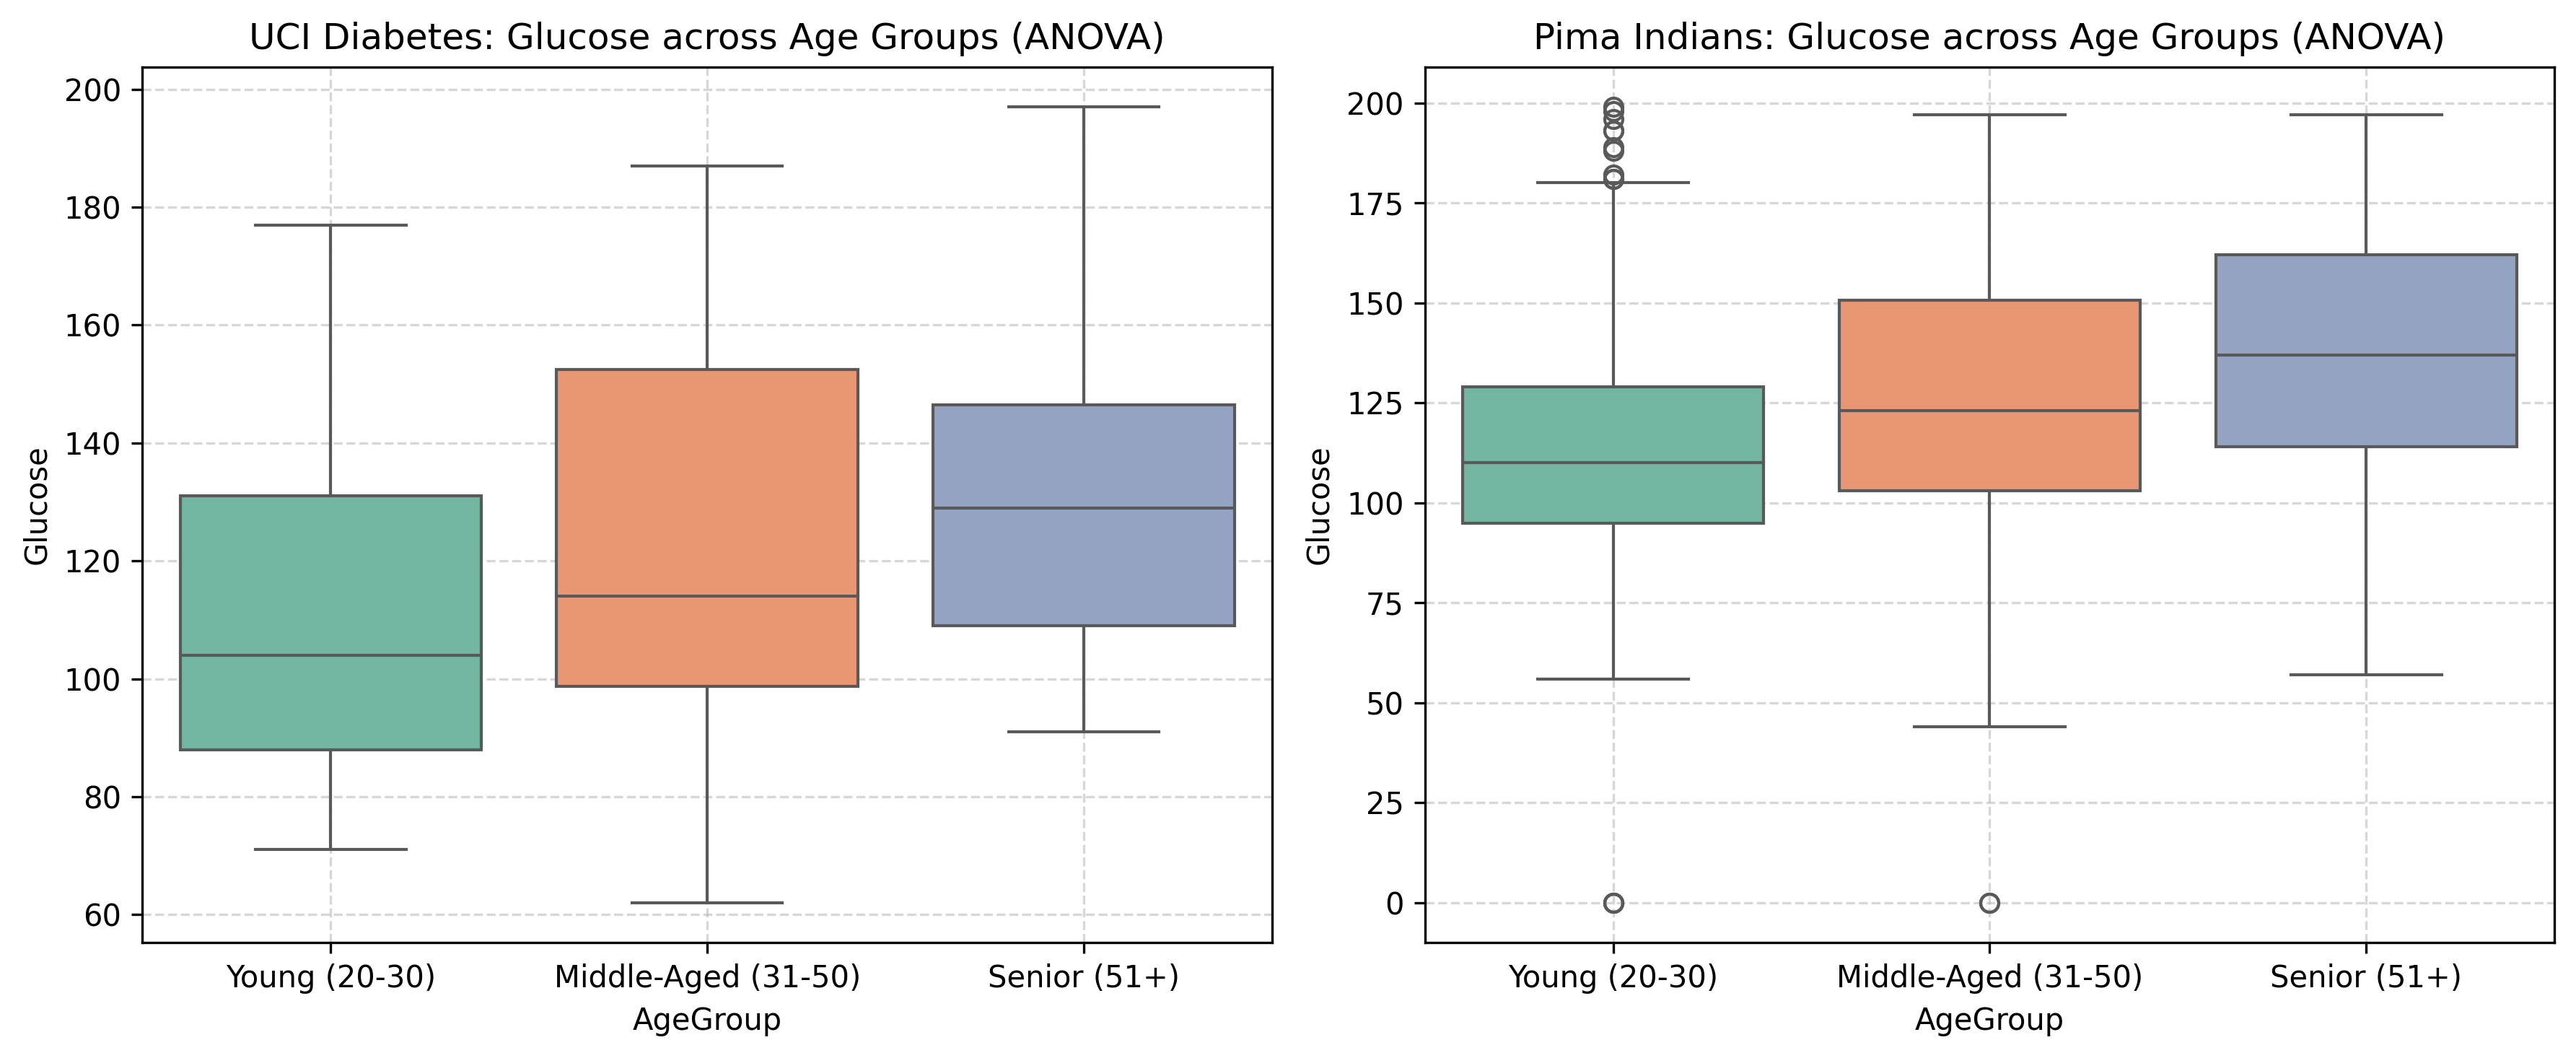

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=uci_diabetes, x='AgeGroup', y='Glucose', ax=axes[0], palette='Set2')
axes[0].set_title('UCI Diabetes: Glucose across Age Groups (ANOVA)')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.boxplot(data=pima_diabetes, x='AgeGroup', y='Glucose', ax=axes[1], palette='Set2')
axes[1].set_title('Pima Indians: Glucose across Age Groups (ANOVA)')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()